# JKO Flow & Porous Medium Equation

## Gradient Flows in Wasserstein Space

The **Jordan–Kinderlehrer–Otto (JKO) scheme** (1998) provides a variational interpretation of diffusion equations as **gradient flows** in the space of probability measures equipped with the Wasserstein-2 metric $W_2$.

Given a functional $\mathcal{F}[\rho]$ over probability densities, the JKO implicit Euler scheme is:
$$\rho^{n+1} = \arg\min_{\rho} \left\{ \frac{1}{2\tau} W_2^2(\rho, \rho^n) + \mathcal{F}[\rho] \right\}$$

This converges as $\tau \to 0$ to the PDE: $\partial_t \rho = \nabla \cdot \left(\rho \nabla \frac{\delta \mathcal{F}}{\delta \rho}\right)$

## The Porous Medium Equation

With the **Rényi entropy** $\mathcal{F}[\rho] = \frac{1}{m-1} \int \rho^m$, the JKO flow produces the **porous medium equation** (PME):
$$\partial_t \rho = \Delta(\rho^m) = \nabla \cdot (m \rho^{m-1} \nabla \rho)$$

- $m = 1$: standard **heat equation** (linear diffusion)
- $m > 1$: **slow diffusion** — the solution has compact support (free boundary)
- $m < 1$: **fast diffusion** — solution spreads immediately to infinity

## Barenblatt Solution

For $m > 1$, the exact self-similar solution is the **Barenblatt profile**:
$$\rho_B(x,t) = t^{-\alpha} \left(C - k \left|\frac{x}{t^\beta}\right|^2\right)_+^{1/(m-1)}$$

with $\alpha = 1/(m + 1)$, $\beta = \alpha / 2$, $k = (m-1)/(2m(m+1))$.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

### 1D Porous Medium Equation via finite differences

We solve the PME $\partial_t \rho = \partial_{xx}(\rho^m)$ on a 1D periodic domain using explicit finite differences. The nonlinear flux $H(\rho) = \rho^m$ makes this a degenerate parabolic equation.

The discrete scheme:
$$\rho_j^{n+1} = \rho_j^n - \frac{\tau}{2}(H(\rho_{j+1}^n) - 2H(\rho_j^n) + H(\rho_{j-1}^n))$$

In [2]:
n = 256
x = np.linspace(0, 1, n + 1)[:-1]  # periodic

def laplacian_1d(f):
    """Discrete Laplacian with periodic BC."""
    return (np.roll(f, -1) + np.roll(f, 1) - 2*f) / 2

def run_pme(m, n_steps, tau=0.05, x=x):
    """Simulate PME: d rho/dt = Delta(rho^m)."""
    # Initial condition: compact bump
    rho = np.maximum(1 - ((x - 0.5) / 0.15)**2, 0)
    rho = rho / rho.sum()  # normalize mass

    snaps = [rho.copy()]
    for _ in range(n_steps):
        rho = rho - tau * laplacian_1d(rho**m)
        rho = np.maximum(rho, 0)
        snaps.append(rho.copy())
    return np.array(snaps)

# Run for several values of m
m_values = [1, 1.5, 2, 4]
n_steps = 80
tau = 0.03

results = {m: run_pme(m, n_steps, tau=tau) for m in m_values}

### Evolution for different exponents $m$

We compare the density profiles at multiple time steps for $m=1$ (heat equation) and $m > 1$ (porous medium). The key difference is the **compact support** property: for $m > 1$, the density is identically zero outside a moving boundary.

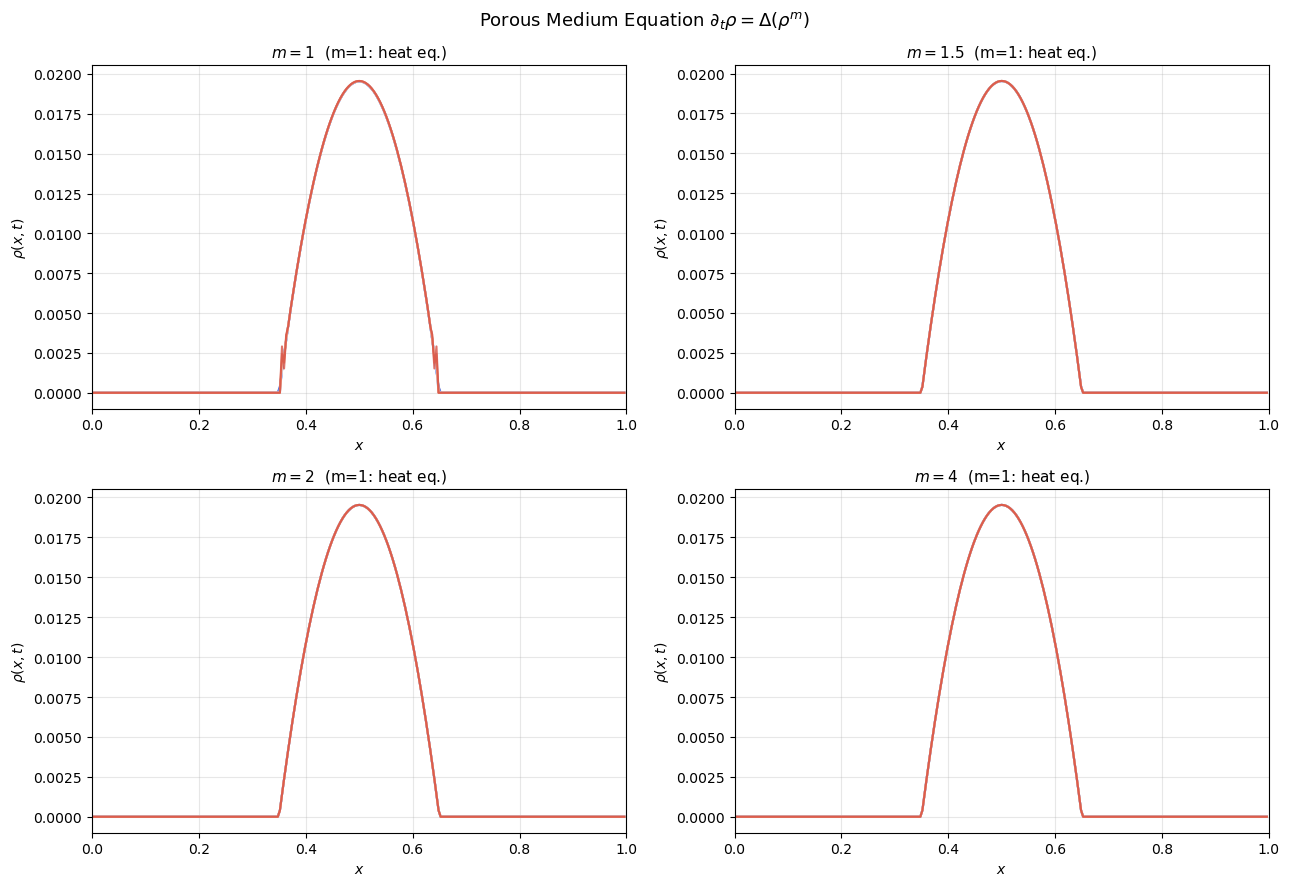

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, m in zip(axes.ravel(), m_values):
    snaps = results[m]
    n_show = 10
    indices = np.linspace(0, len(snaps)-1, n_show, dtype=int)
    for k, i in enumerate(indices):
        t = (1 - k/n_show)
        color = plt.cm.coolwarm(k / n_show)
        ax.plot(x, snaps[i], color=color, lw=1.5, alpha=0.8)
    ax.set_title(f'$m = {m}$  (m=1: heat eq.)', fontsize=11)
    ax.set_xlabel('$x$'); ax.set_ylabel('$\\rho(x,t)$')
    ax.set_xlim(0, 1); ax.set_ylim(-0.001, None)
    ax.grid(True, alpha=0.3)

plt.suptitle('Porous Medium Equation $\\partial_t \\rho = \\Delta(\\rho^m)$', fontsize=13)
plt.tight_layout(); plt.savefig('pme_evolution.png', dpi=100, bbox_inches='tight'); plt.show()

### Barenblatt self-similar solution

The **Barenblatt profile** is the exact self-similar solution for the PME on $\mathbb{R}$ with $m > 1$:
$$\rho_B(x,t) = t^{-\alpha} \left(C - \frac{(m-1)}{2m(m+1)} \frac{x^2}{t^{2\beta}}\right)_+^{1/(m-1)}$$

where $\alpha = 1/(m+1)$, $\beta = \alpha/2$, and $C$ is chosen to fix total mass = 1.

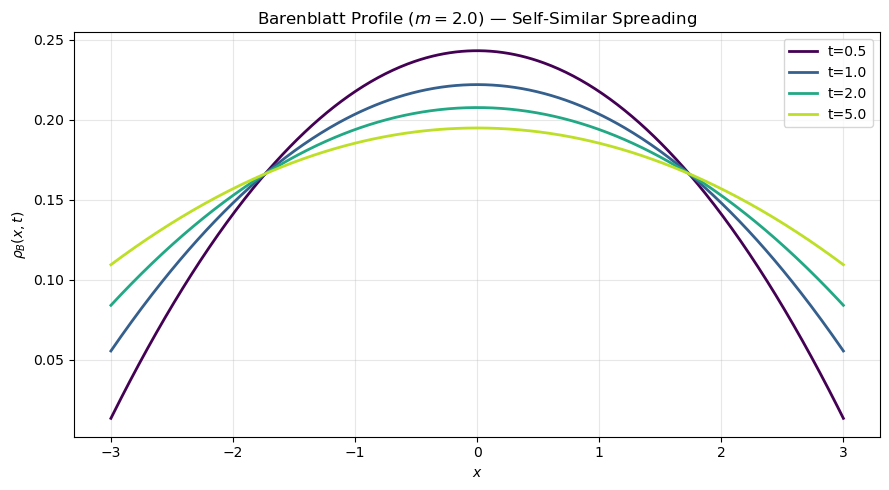

In [4]:
def barenblatt(x, t, m, mass=1.0):
    """Barenblatt self-similar solution for PME (m>1)."""
    alpha = 1.0 / (m + 1)
    beta = alpha / 2
    k = (m - 1) / (2 * m * (m + 1))
    # C chosen for unit mass via numerical normalization
    xi = x / t**beta
    profile = np.maximum(1 - k * xi**2, 0) ** (1.0 / (m - 1))
    # Rescale by t^{-alpha} and normalize mass
    profile = t**(-alpha) * profile
    dx = x[1] - x[0] if hasattr(x, '__len__') else 1.0
    profile_mass = np.sum(profile) * dx
    if profile_mass > 0:
        profile = profile * mass / profile_mass
    return profile

x_full = np.linspace(-3, 3, 500)
t_vals = [0.5, 1.0, 2.0, 5.0]
m_bar = 2.0

fig, ax = plt.subplots(figsize=(9, 5))
cols = plt.cm.viridis(np.linspace(0, 0.9, len(t_vals)))
for t, col in zip(t_vals, cols):
    rho_b = barenblatt(x_full, t, m_bar)
    ax.plot(x_full, rho_b, color=col, lw=2, label=f't={t}')

ax.set_xlabel('$x$'); ax.set_ylabel('$\\rho_B(x,t)$')
ax.set_title(f'Barenblatt Profile ($m={m_bar}$) — Self-Similar Spreading')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('barenblatt.png', dpi=100, bbox_inches='tight'); plt.show()

### Free energy dissipation

The PME is a gradient flow for the **Rényi entropy** (or power entropy):
$$\mathcal{F}_m[\rho] = \frac{1}{m-1} \int \rho^m\, dx$$

This is a Lyapunov functional: $\mathcal{F}_m[\rho(\cdot, t)]$ decreases monotonically along the flow.

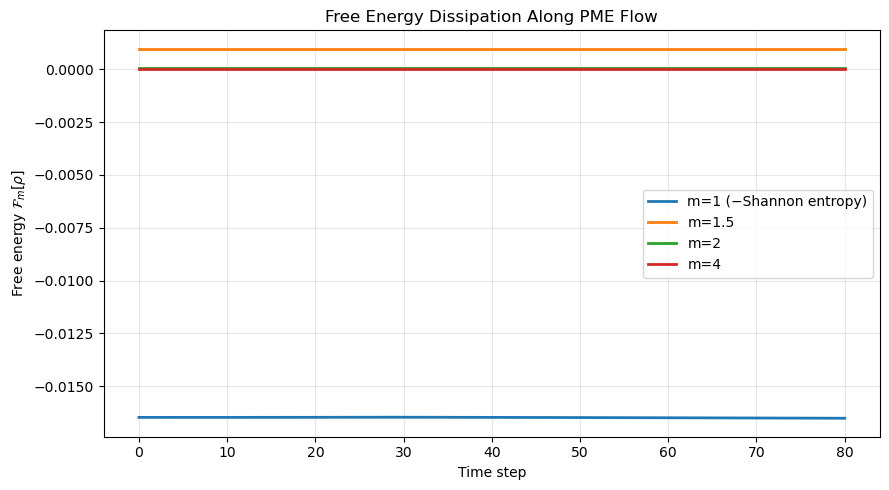

In [5]:
dx = x[1] - x[0]

fig, ax = plt.subplots(figsize=(9, 5))
for m in m_values:
    snaps = results[m]
    if m == 1:
        # Shannon entropy for m=1
        entropy = [-np.sum(rho * np.log(rho + 1e-14)) * dx for rho in snaps]
        label = f'm=1 (−Shannon entropy)'
        # Negate so it's decreasing
        entropy = [-e for e in entropy]
    else:
        entropy = [np.sum(rho**m) * dx / (m-1) for rho in snaps]
        label = f'm={m}'
    ax.plot(entropy, lw=2, label=label)

ax.set_xlabel('Time step'); ax.set_ylabel('Free energy $\\mathcal{F}_m[\\rho]$')
ax.set_title('Free Energy Dissipation Along PME Flow')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('pme_energy.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: PME with varying exponent

In [ ]:
def show_pme(m=2.0, n_steps=60):
    snaps_i = run_pme(m, n_steps, tau=0.03)
    n_show_i = 8
    idx_i = np.linspace(0, len(snaps_i)-1, n_show_i, dtype=int)

    fig, ax = plt.subplots(figsize=(9, 5))
    for k, i in enumerate(idx_i):
        col = plt.cm.coolwarm(k / n_show_i)
        ax.plot(x, snaps_i[i], color=col, lw=2, alpha=0.8, label=f't={i}')
    ax.set_title(f'PME with $m={m:.2f}$')
    ax.set_xlabel('$x$'); ax.set_xlim(0, 1); ax.set_ylim(-0.001, None)
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_pme,
         m=FloatSlider(min=0.5, max=5.0, step=0.25, value=2.0, description='m'),
         n_steps=IntSlider(min=20, max=200, step=20, value=60));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 2, figsize=(12, 9))
    for ax, m in zip(axes.ravel(), m_values):
        snaps_s = results[m]
        indices_s = np.linspace(0, len(snaps_s)-1, 8, dtype=int)
        for k, i in enumerate(indices_s):
            ax.plot(x, snaps_s[i], color=_plt.cm.coolwarm(k/8), lw=1.5, alpha=0.8)
        ax.set_title(f'm={m}', fontsize=11)
        ax.set_xlabel('$x$'); ax.set_xlim(0, 1)
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- The JKO scheme reveals that many diffusion equations are **gradient flows** in Wasserstein space.
- The PME $\partial_t \rho = \Delta(\rho^m)$ interpolates between the heat equation ($m=1$) and fully degenerate diffusion ($m \gg 1$).
- For $m > 1$, solutions have **compact support** — a genuine free boundary problem.
- The **Barenblatt profile** is the exact self-similar attractor for the PME.

## Bibliography

- R. Jordan, D. Kinderlehrer & F. Otto, *The variational formulation of the Fokker–Planck equation*, SIAM J. Math. Anal. 29, 1998.
- J. L. Vázquez, *The Porous Medium Equation*, Oxford UP, 2007.
- C. Villani, *Topics in Optimal Transportation*, AMS, 2003.